Enter names of students working in a team of two here: [Firstname Surname] [Firstname Surname]

# SIG Exercise 1 - Signals and Systems

Necessary imports (run this block before any other code):

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage

## Section 1: Plane waves

A plane wave in two dimensions is described by $ f(x, y) = e^{i(k_{x}x + k_{y}y)} $, with $k_x, k_y \in \mathbb{R}$. 

### Task 1.1
Write a program that calculates a 2D plane wave for any given $k_x$, $k_y$.

In [ ]:
# Type your code in this cell:
def planewave(kx, ky, x, y):
    wave = np.exp(1j*(kx*x + ky*y))
    return wave

### Task 1.2
Display and examine Re(f), Im(f), Abs(f), and Phase(f) for a selection of $k_x$, $k_y$.

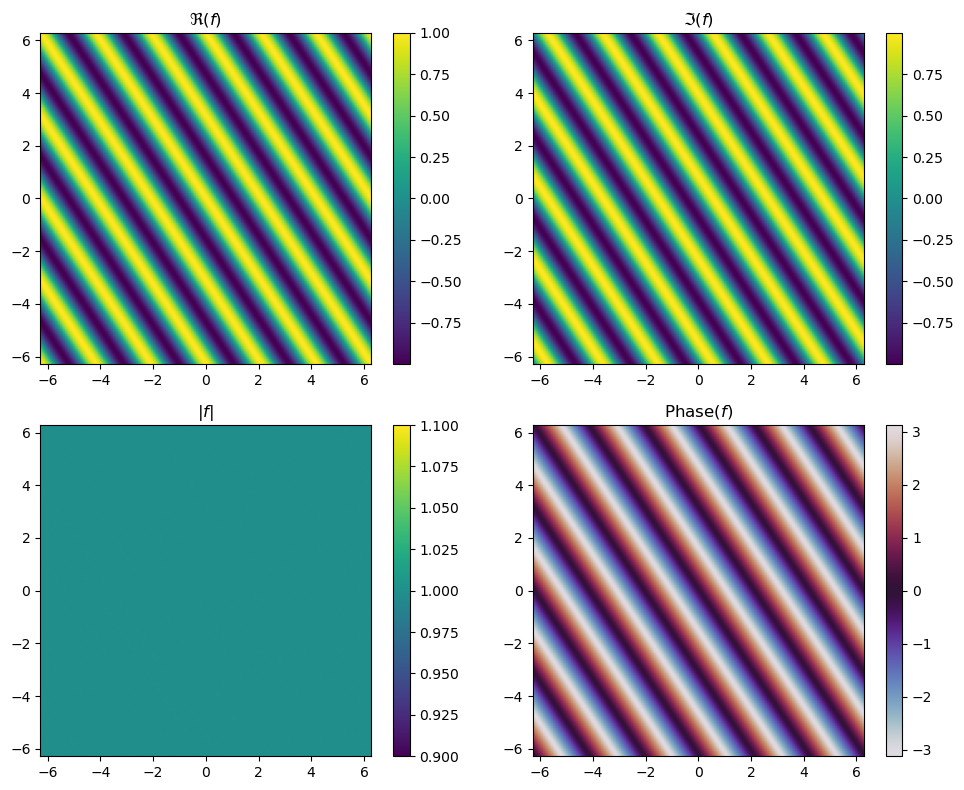

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create a grid of x, y values
x = np.linspace(-2*np.pi, 2*np.pi, 200)
y = np.linspace(-2*np.pi, 2*np.pi, 200)
X, Y = np.meshgrid(x, y)

# Choose some kx, ky values
kx, ky = 3, 2
f = planewave(kx, ky, X, Y)

# Extract components
f_real = np.real(f)
f_imag = np.imag(f)
f_abs  = np.abs(f)
f_phase = np.angle(f)

# Plot results
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

im0 = axs[0,0].imshow(f_real, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower')
axs[0,0].set_title(r"$\Re(f)$")
plt.colorbar(im0, ax=axs[0,0])

im1 = axs[0,1].imshow(f_imag, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower')
axs[0,1].set_title(r"$\Im(f)$")
plt.colorbar(im1, ax=axs[0,1])

im2 = axs[1,0].imshow(f_abs, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower')
axs[1,0].set_title(r"$|f|$")
plt.colorbar(im2, ax=axs[1,0])

im3 = axs[1,1].imshow(f_phase, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower', cmap='twilight')
axs[1,1].set_title(r"$\text{Phase}(f)$")
plt.colorbar(im3, ax=axs[1,1])

plt.tight_layout()
plt.show()


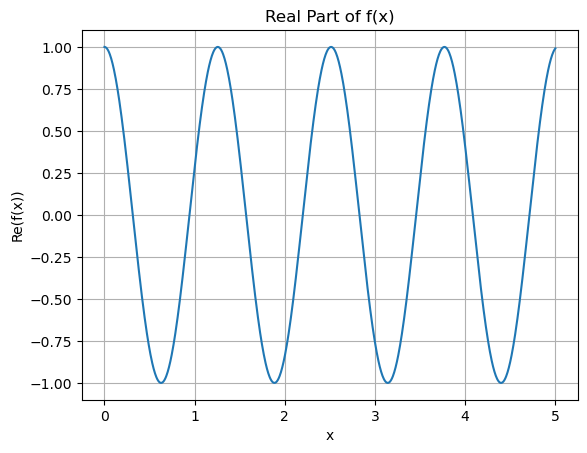

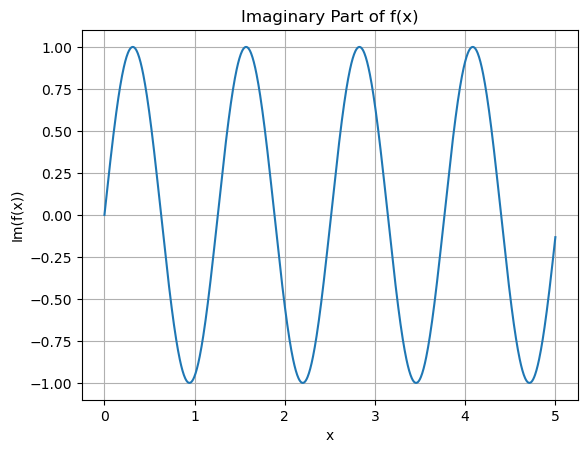

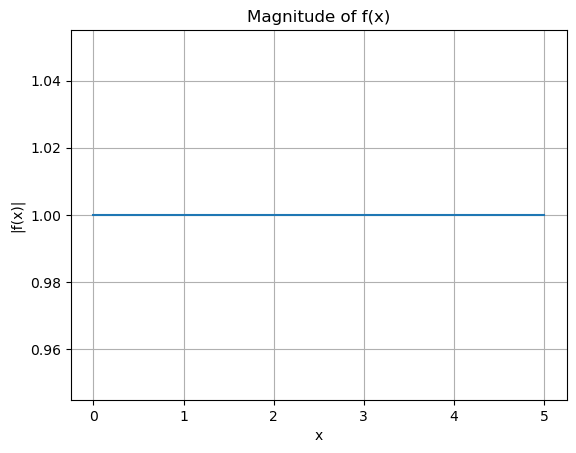

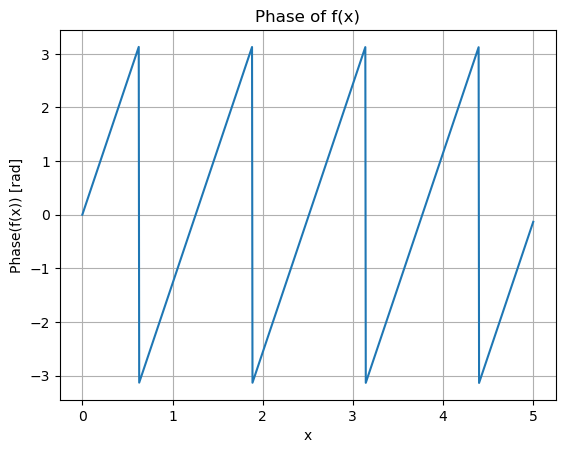

In [ ]:
# Type your code in this cell:
x = np.linspace(0,5,1000)
y = np.linspace(0,5,1000)

f = planewave(3,2,x,y) #kx = 3, ky 2

# Real part
plt.plot(x, np.real(f))
plt.title("Real Part of f(x)")
plt.xlabel("x")
plt.ylabel("Re(f(x))")
plt.grid(True)
plt.show()

# Imaginary part
plt.plot(x, np.imag(f))
plt.title("Imaginary Part of f(x)")
plt.xlabel("x")
plt.ylabel("Im(f(x))")
plt.grid(True)
plt.show()

# Magnitude
plt.plot(x, np.abs(f))
plt.title("Magnitude of f(x)")
plt.xlabel("x")
plt.ylabel("|f(x)|")
plt.grid(True)
plt.show()

# Phase
plt.plot(x, np.angle(f))
plt.title("Phase of f(x)")
plt.xlabel("x")
plt.ylabel("Phase(f(x)) [rad]")
plt.grid(True)
plt.show()


### Task 1.3
What determines the direction of the wave?

The direction of the signal is the vector $(k_x, k_y)$.
The angle $\theta$ of the wave with respect to the $x$-axis is

$$
\theta = \arctan\left(\frac{k_y}{k_x}\right).
$$


### Task 1.4
What is the wavelength as a function of $k_x$, $k_y$?

The wavelength is defined as:

$$
\lambda(k_x, k_y) = \frac{2\pi}{\sqrt{k_x^2 + k_y^2}}
$$


### Task 1.5
Think of some linear, shift-invariant (LSI) operation and apply it to the plane wave.

*Type your answer in this cell:*

In [ ]:
# Shift parameters 
x0, y0 = 1.0, 0.5

#shifted wave
f_shifted = np.exp(-1j*(3*x0 + 2*y0)) * f

### Task 1.6
What happens to the wave?

When we shift a 2D signal \(f(x,y)\) by \((x_0, y_0)\), the shifted signal is  

$$
f_{\text{shifted}}(x,y) = f(x - x_0,\, y - y_0).
$$

For the plane wave  

$$
f(x,y) = e^{j(k_x x + k_y y)},
$$

the shifted version becomes  

$$
f_{\text{shifted}}(x,y) = e^{j(k_x (x - x_0) + k_y (y - y_0))}.
$$

This can be rewritten as  

$$
f_{\text{shifted}}(x,y) = e^{-j(k_x x_0 + k_y y_0)} \cdot e^{j(k_x x + k_y y)}.
$$

**In words:** Shifting a plane wave by \((x_0, y_0)\) does not change its shape.  
It only multiplies the original wave by a constant complex phase factor  
$$e^{-j(k_x x_0 + k_y y_0)}.$$


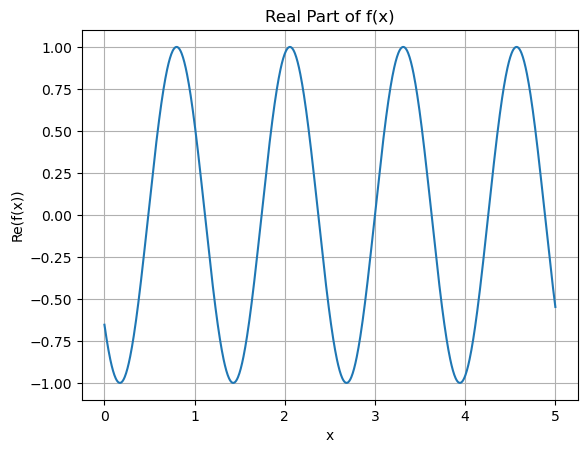

In [20]:
# Real part
plt.plot(x, np.real(f_shifted))
plt.title("Real Part of f(x)")
plt.xlabel("x")
plt.ylabel("Re(f(x))")
plt.grid(True)
plt.show()

On the figure above, we can see that the real signal has been shifted from starting at 90 degrees (cosine) to 0.8 units horizontally to the right.  

This is because the plot advances along the line where x and y increase together.  

The shift can be calculated:  

Since along the line $y = x$, the effective signal is  

$$
g(x) = e^{j(3x + 2x)} = e^{j \cdot 5x}.
$$

Our shifted signal becomes  

$$
g_{\text{shifted}}(x) = e^{-j(3 \cdot 1 + 2 \cdot 0.5)} \, e^{j5x} = e^{-j4} \, e^{j5x}.
$$

That is equivalent to  

$$
g_{\text{shifted}}(x) = e^{j5(x - 0.8)}.
$$

In real terms:  

$$
\Re \big( g_{\text{shifted}}(x) \big) = \cos \big( 5(x - 0.8) \big).
$$


## Section 2: Fast Fourier Transform

This section studies the behavior of the fast Fourier transform (FFT) using a rectangle signal as input: the prepared 1D input vector is of length 256 and has a rectangle of length 16 at the center. Run the code and answer the questions.

In [9]:
n = 256
m = 16

rect = np.zeros(n)
ind1 = int(n/2-m/2)
ind2 = int(n/2+m/2)
rect[ind1:ind2] = 1

The following code cell calculates and displays the FFT of the input vector straightforwardly.

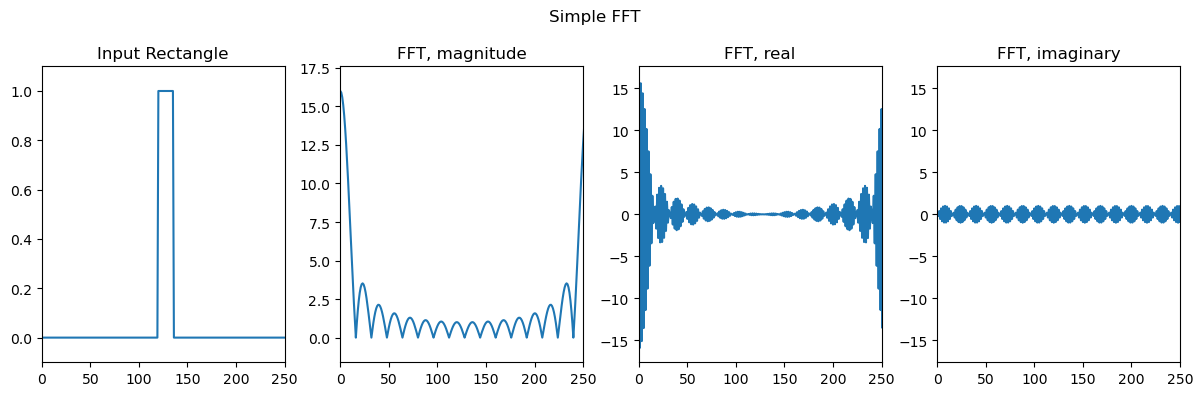

In [10]:
trafo = np.fft.fft(rect)

# define plot ranges
range1 = [-0.1, 1.1];                                                          
range2 = np.multiply([-0.1, 1.1], max(abs(trafo)))
range3 = np.multiply([-0.3, 1.1], max(abs(trafo)))                                                                  
range4 = np.multiply([-1.1, 1.1], max(abs(trafo)))

yranges = [range1, range2, range4, range4]
titles = ["Input Rectangle", "FFT, magnitude", "FFT, real", "FFT, imaginary"]
arrays_to_plot = [rect, np.abs(trafo), np.real(trafo), np.imag(trafo)]

fig, axes = plt.subplots(1, 4, figsize=(12, 4))
fig.suptitle("Simple FFT")
for i in range(4):
    axes[i].plot(arrays_to_plot[i])
    axes[i].set_ylim(yranges[i])
    axes[i].set_xlim([0, 250])
    axes[i].set_title(titles[i])
fig.tight_layout() 

### Task 2.1
Why is the sinc-shaped Fourier transform split in two halves?

*Type your answer in this cell: because the negative frequency components are "wrapped" to the end of the fft. The second half of the fft are actually the negative frequencies.*

The next code cell performs 'fftshift' on the transform, which swaps its first and second halves. 

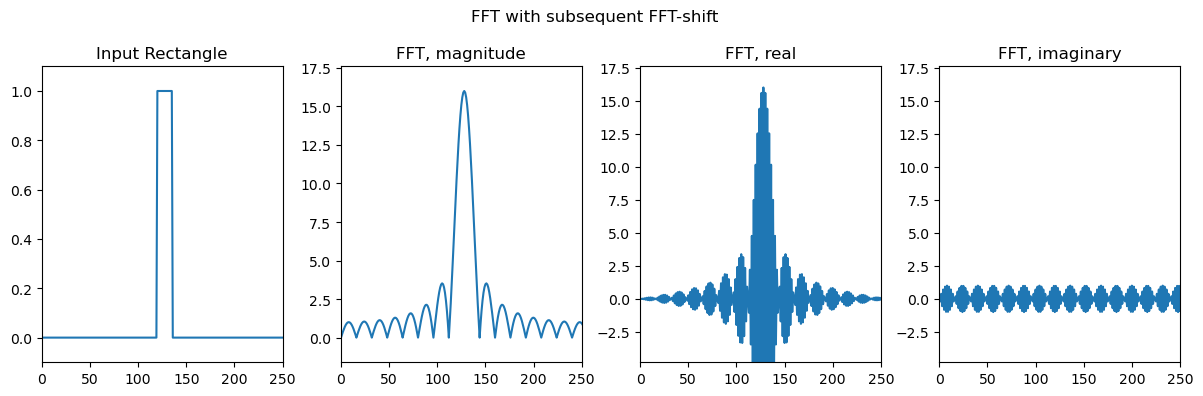

In [11]:
trafo = np.fft.fftshift(np.fft.fft(rect))

yranges = [range1, range2, range3, range3]
arrays_to_plot = [rect, np.abs(trafo), np.real(trafo), np.imag(trafo)]
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
fig.suptitle("FFT with subsequent FFT-shift")
for i in range(4):
    axes[i].plot(arrays_to_plot[i])
    axes[i].set_ylim(yranges[i])
    axes[i].set_xlim([0, 250])
    axes[i].set_title(titles[i])   
fig.tight_layout()

### Task 2.2
Why does the phase of the transform oscillate rapidly? Isn’t the rectangle symmetric so that the transform should be purely real?

*Type your answer in this cell: Yes, an fft of a rectangle symmetric in the x=0 axis would be purely real, but the initial rectangle pulse is shifted to the right. A shift in spacial domain corresponds to a complex exponential (phase) in the k-domain. This complex exponential provides little oscillations in both the real and imaginary part of the signal.*

The next code cell includes phase correction, shifting the origin in the original domain to the center of the rectangle. Review the related lecture notes.

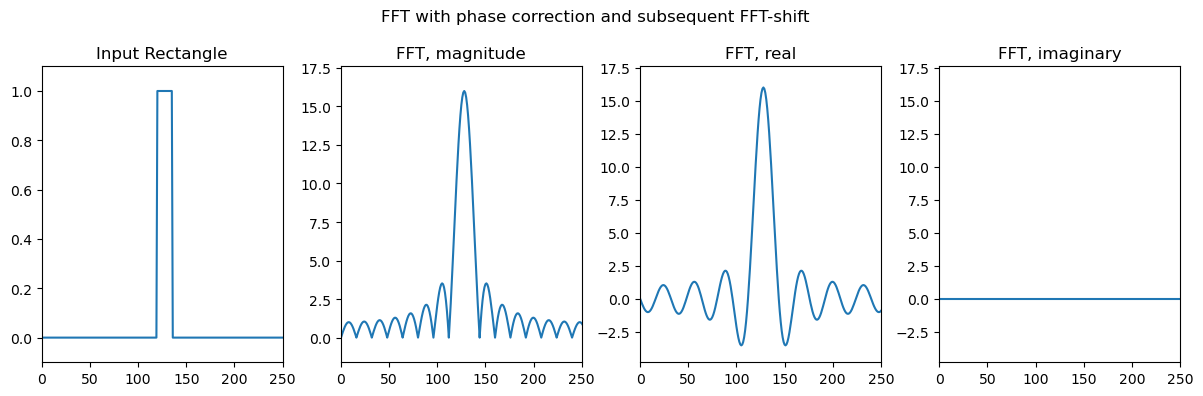

In [12]:
delta_k = 2*np.pi/n      #n=256: length of signal                   # calculate sample spacing in the Fourier domain
ind1 = int(-n/2)
ind2 = int(n/2)
index_array = np.arange(ind1,ind2)
k = np.multiply(index_array,delta_k)                                # create vector of sampling positions in the Fourier domain
x0 = -(n-1)/2                                                       # actual position of first input sample
trafo = np.exp(-1j*k*x0)*np.fft.fftshift(np.fft.fft(rect))          # include phase correction after FFT

arrays_to_plot = [rect, np.abs(trafo), np.real(trafo), np.imag(trafo)]
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
fig.suptitle("FFT with phase correction and subsequent FFT-shift")
for i in range(4):
    axes[i].plot(arrays_to_plot[i])
    axes[i].set_ylim(yranges[i])
    axes[i].set_xlim([0, 250])
    axes[i].set_title(titles[i])   
fig.tight_layout()

The next code cell attempts to shift the origin simply by fftshift instead, similar to what it does in the Fourier domain.

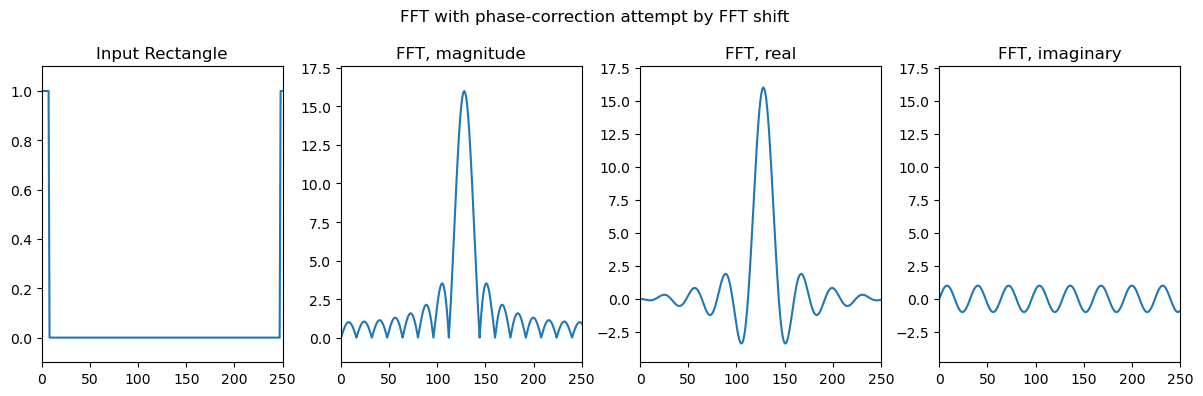

In [13]:
trafo = np.fft.fftshift(np.fft.fft(np.fft.fftshift(rect)))

arrays_to_plot = [np.fft.fftshift(rect), np.abs(trafo), np.real(trafo), np.imag(trafo)]
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
fig.suptitle("FFT with phase-correction attempt by FFT shift")
for i in range(4):
    axes[i].plot(arrays_to_plot[i])
    axes[i].set_ylim(yranges[i])
    axes[i].set_xlim([0, 250])
    axes[i].set_title(titles[i])   
fig.tight_layout()

### Task 2.3
As you see, this works only almost. Why doesn’t it work fully?

*Type your answer in this cell: np.fft.fftshift() "swaps" the first and second half of the signal. Applying this on a signal with a pulse halfway in the signal, results in one narrower pulse at t=0 and one narrower pulse at the end of the signal. This pulse at the end of the signal, is again shifted in spacial-domain, thus contains a phase in the k-domain.*

## Section 3: Build a comb

### Task 3.1
Build a 1D comb function by starting with a single point impulse in the center and successively adding impulses on the left and right. At each stage, calculate and examine the Fourier transform. What happens?

IndexError: index 256 is out of bounds for axis 0 with size 256

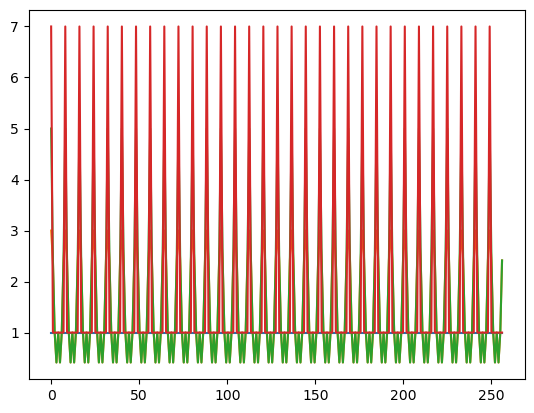

In [4]:
# Type your code in this cell:
n=256
m=32 #width of original comb

impulsetrain = np.zeros(n)
for i in range(100):
    impulsetrain[(int(n/2) + i*m)] = 1    #n/2 is the middle, each iteration the for loop will add one impulse 16 indices to the right and left.
    impulsetrain[(int(n/2) - i*m)] = 1
    fft = np.fft.fftshift(np.fft.fft(impulsetrain))
    k = np.linspace(0,n,n)   #STILL NEED TO MAKE THIS AXIS REALISTIC
    plt.plot(k, np.abs(fft), label=f'Step {i+1}: {2*i+1} impulses')

plt.title("FFT")
plt.xlabel("k")
plt.ylabel("Magnitude")
plt.grid(True)
plt.legend()
plt.show()

impulsetrain = np.zeros(100)
for i in range(4):
    impulsetrain[(int(n/2) + i*m)] = 1    #n/2 is the middle, each iteration the for loop will add one impulse 16 indices to the right and left.
    impulsetrain[(int(n/2) - i*m)] = 1
    fft = np.fft.fftshift(np.fft.fft(impulsetrain))
    k = np.linspace(0,n,n)   #STILL NEED TO MAKE THIS AXIS REALISTIC
    plt.plot(k, np.abs(fft), label=f'Step {i+1}: {2*i+1} impulses')

plt.title("FFT, zoomed in")
plt.xlabel("k")
plt.ylabel("Magnitude")
plt.grid(True)
plt.xlim(4, 12)  # zoom in
plt.legend()
plt.show()



*Type your answer in this cell: when there is only one dirac in the signal, the fft is constant. When we add more diracs, a comb begins to appear.* 

### Task 3.2
What happens when you vary $\Delta x$ of the original comb?

*Type your answer in this cell: the spacing in the k-domain gets narrower with widening in the x-domain. This is to be expected as $\Delta k = \frac{2\pi}{\Delta x}$*

LULU